Partie 1 – Explorer les données
1) Charger les données CSV ;

In [1]:
import pandas as pd

df = pd.read_csv("../data/smart_building_raw.csv")

2) Afficher les premières lignes du dataset ;

In [2]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


3) Afficher les dernières lignes du dataset ;

In [3]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


4) Combien d'observations contient le dataset ?

In [4]:
print("Nombre d'observations :", df.shape[0])

Nombre d'observations : 507


In [5]:
5) Combien de variables possède le dataset ?

SyntaxError: unmatched ')' (1609612537.py, line 1)

In [ ]:
print("Nombre de variables :", df.shape[1])

Nombre de variables : 14


6) Identifier les variables numériques ;

In [ ]:
print(df.select_dtypes(include="number").columns.tolist())

['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


7) Identifier les variables catégorielles ;

In [ ]:
df.select_dtypes(include="object").columns.tolist()

['date',
 'batiment',
 'type_batiment',
 'zone',
 'mode_climatisation',
 'etat_systeme',
 'jour_semaine',
 'alerte']

8) Identifier les dates

In [ ]:
print(df.dtypes)

id_mesure               int64
date                   object
batiment               object
type_batiment          object
zone                   object
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation     object
etat_systeme           object
jour_semaine           object
alerte                 object
dtype: object


In [ ]:
print(df.date)

0     2025-02-13 06:00:00
1     2025-03-10 12:00:00
2     2025-05-04 00:00:00
3     2025-01-19 00:00:00
4     2025-04-24 06:00:00
              ...        
502   2025-01-27 12:00:00
503   2025-03-09 12:00:00
504   2025-03-29 00:00:00
505   2025-04-19 18:00:00
506   2025-01-26 12:00:00
Name: date, Length: 507, dtype: datetime64[ns]


9) Identifier les identifiants

In [ ]:
colonnes_id = [col for col in df.columns if "id" in col.lower()]

print("Colonnes pouvant être des identifiants :", colonnes_id)

Colonnes pouvant être des identifiants : ['id_mesure', 'humidite']


0      1174
1      1275
2      1493
3      1073
4      1454
       ... 
502    1107
503    1271
504    1349
505    1436
506    1103
Name: id_mesure, Length: 507, dtype: int64

10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [ ]:
df.describe()

,id_mesure,date,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,502,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,2025-03-04 13:26:03.346613504,24.154141,57.864113,844.150000,44.850299,169.069323
min,1001.000000,2025-01-01 00:00:00,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,2025-02-01 01:30:00,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,2025-03-04 21:00:00,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,2025-04-04 22:30:00,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,2025-05-05 18:00:00,96.000000,160.000000,6000.000000,116.000000,336.200000
std,144.782769,NaN,7.418465,16.026336,582.181386,24.949139,53.164294


11) Y a-t-il des variables potentiellement problématiques ?

In [ ]:
print("valeurs manquantes : ")
df.isnull().sum()

valeurs manquantes : 


id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

In [ ]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 7


In [ ]:
#Variables avec très peu de valeurs différentes

for colonne in df.columns:
    print(colonne, ":", df[colonne].nunique(), "valeurs uniques")

id_mesure : 500 valeurs uniques
date : 495 valeurs uniques
batiment : 8 valeurs uniques
type_batiment : 16 valeurs uniques
zone : 4 valeurs uniques
temperature : 144 valeurs uniques
humidite : 305 valeurs uniques
co2 : 392 valeurs uniques
occupation : 108 valeurs uniques
consommation_kwh : 445 valeurs uniques
mode_climatisation : 7 valeurs uniques
etat_systeme : 3 valeurs uniques
jour_semaine : 7 valeurs uniques
alerte : 2 valeurs uniques


In [ ]:
#variables categorielle

print("variables categorielles : ", df.select_dtypes(include="object"))

variables categorielles :      batiment      type_batiment zone mode_climatisation etat_systeme  \
0         B8           Entrepôt    A                Eco       Normal   
1         B7             Bureau    D                Eco       Normal   
2         B5  Centre commercial    B             Normal       Normal   
3         B6         Université    D             Normal       Normal   
4         B7             Bureau    D             Normal       Normal   
..       ...                ...  ...                ...          ...   
502       B2              École    C             Normal       Normal   
503       B3            Hôpital    B                Eco       Alerte   
504       B5  Centre commercial    B                Eco       Normal   
505       B7             Bureau    C              Boost       Normal   
506       B2              École    D             Normal        Panne   

    jour_semaine alerte  
0          Jeudi    Non  
1          Lundi    Non  
2       Dimanche    Oui  
3   

12) Pour les données incohérentes :

a) rechercher des valeurs telles que humidité < 0 ;

In [ ]:
df[df["humidite"] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


b) rechercher des valeurs telles que humidité > 100 ;

In [ ]:
df[df["humidite"] > 100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


c) rechercher des valeurs telles que température extrêmement élevée ;

In [ ]:
print(df["temperature"].describe())

count    495.000000
mean      24.154141
std        7.418465
min      -30.000000
25%       21.600000
50%       24.000000
75%       26.000000
max       96.000000
Name: temperature, dtype: float64


In [ ]:
df.nlargest(10, "temperature") #afficher les 10 plus grandes valeurs de la colonne temperature

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
116,1181,2025-02-15 00:00:00,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
499,1021,2025-01-06 00:00:00,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non
161,1061,2025-01-16 00:00:00,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
7,1141,2025-02-05 00:00:00,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
157,1361,2025-04-01 00:00:00,B3,Hôpital,D,34.2,60.9,828.0,41.0,270.3,Normal,Normal,Mardi,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
419,1191,2025-02-17 12:00:00,B2,École,D,31.6,NaN,1057.0,57.0,255.3,BOOST,Normal,Lundi,Oui
48,1472,2025-04-28 18:00:00,B3,Hôpital,C,31.2,58.1,531.0,30.0,224.2,Boost,Normal,Lundi,Non
370,1268,2025-03-08 18:00:00,B1,Bureau,B,30.6,60.6,684.0,0.0,179.4,Normal,Normal,Samedi,Non
393,1157,2025-02-09 00:00:00,B8,Entrepôt,B,30.6,33.0,241.0,113.0,319.5,Boost,Normal,Dimanche,Non


d) rechercher des valeurs telles que négative ;

In [ ]:
colonnes_numeriques = df.select_dtypes(include="number").columns

for colonne in colonnes_numeriques:
    valeurs_negatives = df[df[colonne] < 0]
    
    if not valeurs_negatives.empty:
        print(f"\n{colonne} :")
        print(valeurs_negatives[[colonne]])


temperature :
     temperature
185        -25.0
358        -30.0

humidite :
     humidite
281      -5.0
335      -8.0
366     -12.0

occupation :
     occupation
22         -5.0
376        -8.0
430       -12.0
487        -2.0
494       -20.0

consommation_kwh :
     consommation_kwh
59              -15.0
154             -50.0
199             -20.0
441            -100.0


e) rechercher des valeurs telles que consommation négative ;

In [ ]:
df[df["consommation_kwh"] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante

In [ ]:
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = pd.NA

In [ ]:
print(df[df["humidite"] < 0])

     id_mesure                date batiment type_batiment zone  temperature  \
281       1126 2025-02-01 06:00:00       B2         École    D         24.8   
335       1036 2025-01-09 18:00:00       B4        Bureau    D         21.2   
366       1216 2025-02-23 18:00:00       B3       Hôpital    B         23.2   

     humidite    co2  occupation  consommation_kwh mode_climatisation  \
281      -5.0  759.0        57.0             225.2              Boost   
335      -8.0  160.0        25.0             120.2             Normal   
366     -12.0  702.0        41.0             119.8             Normal   

    etat_systeme jour_semaine alerte  
281       Normal       Samedi    Non  
335       Alerte        Jeudi    Non  
366       Normal     Dimanche    Non  


In [ ]:
print(df[df["humidite"] > 100])

     id_mesure                date batiment      type_batiment zone  \
59        1246 2025-03-03 06:00:00       B5  Centre commercial    A   
103       1016 2025-01-04 18:00:00       B6         Université    B   
128       1156 2025-02-08 18:00:00       B1             Bureau    A   
160       1186 2025-02-16 06:00:00       B8           Entrepôt    B   
268       1276 2025-03-10 18:00:00       B1             Bureau    D   
327       1066 2025-01-17 06:00:00       B2              École    C   
342       1096 2025-01-24 18:00:00       B8           Entrepôt    A   

     temperature  humidite    co2  occupation  consommation_kwh  \
59          24.2     108.0  813.0        18.0               NaN   
103         26.9     145.0  670.0        28.0             175.9   
128          NaN     160.0  941.0        37.0             149.8   
160         24.9     125.0    NaN        18.0             123.5   
268         26.0     140.0  633.0        25.0             148.3   
327         25.8     132.0  6

In [ ]:
import numpy as np

df.loc[
    (df["humidite"] < 0) | (df["humidite"] > 100),
    "humidite"
] = np.nan

In [ ]:
print(df["humidite"].min())
print(df["humidite"].max())

21.5
90.7


g) rechercher des valeurs telles que catégories mal orthographiées.

In [ ]:
colonnes_categorielles = df.select_dtypes(include="object").columns

print(colonnes_categorielles)

Index(['batiment', 'type_batiment', 'zone', 'mode_climatisation',
       'etat_systeme', 'jour_semaine', 'alerte'],
      dtype='object')


In [ ]:
for colonne in colonnes_categorielles:
    print("\n", colonne)
    print(df[colonne].value_counts())


 batiment
batiment
B1    94
B5    66
B7    65
B2    61
B4    58
B3    58
B8    53
B6    52
Name: count, dtype: int64

 type_batiment
type_batiment
Bureau               210
Centre commercial     65
École                 59
Hôpital               58
Entrepôt              52
Université            48
BUREAU                 2
ÉCOLE                  1
ecole                  1
Bureu                  1
bureau                 1
 UNIVERSITÉ            1
hôpital                1
centre commercial      1
 Bureau                1
entrepot               1
Name: count, dtype: int64

 zone
zone
B    143
A    125
D    124
C    115
Name: count, dtype: int64

 mode_climatisation
mode_climatisation
Normal     271
Eco        131
Boost       96
normal       1
BOOST        1
normale      1
Normal       1
Name: count, dtype: int64

 etat_systeme
etat_systeme
Normal    442
Alerte     52
Panne      13
Name: count, dtype: int64

 jour_semaine
jour_semaine
Vendredi    75
Jeudi       74
Mercredi    73
Samedi      

h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [ ]:
df["type_batiment"] = df["type_batiment"].str.strip()  #supprimer les espaces
df["type_batiment"] = df["type_batiment"].str.lower()  #uniformiser la casse

In [ ]:
print(df["type_batiment"].value_counts())

type_batiment
bureau               214
centre commercial     66
école                 60
hôpital               59
entrepôt              52
université            49
ecole                  1
bureu                  1
entrepot               1
Name: count, dtype: int64


13) Pour les valeurs manquantes

a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [ ]:
print(df.isna().sum())

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              21
co2                    7
occupation             6
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64


In [ ]:
print(df.isna().mean() * 100)

id_mesure             0.000000
date                  0.986193
batiment              0.000000
type_batiment         0.788955
zone                  0.000000
temperature           2.366864
humidite              4.142012
co2                   1.380671
occupation            1.183432
consommation_kwh      1.775148
mode_climatisation    0.986193
etat_systeme          0.000000
jour_semaine          0.986193
alerte                0.000000
dtype: float64


b) Quelle variable possède le plus de valeurs manquantes ?

In [ ]:
print(df.isna().sum().idxmax())

humidite


c) Quelle stratégie utiliser pour les valeurs manquantes ?

Pour les variables numériques, on peut remplacer les valeurs manquantes par la moyenne ou la médiane. Pour les variables catégorielles, on peut utiliser la modalité la plus fréquente (le mode). Le choix dépend de la distribution des données et de la proportion de valeurs manquantes.

d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

On ne doit pas supprimer automatiquement toutes les lignes contenant des valeurs manquantes. Si les valeurs manquantes sont peu nombreuses, on peut envisager une imputation. La suppression peut être utilisée lorsque le nombre de lignes concernées est faible et que leur suppression ne risque pas de dégrader significativement le dataset.

e) Dans quels cas utiliser la moyenne ?

La moyenne est adaptée surtout pour une variable numérique lorsque les valeurs sont relativement équilibrées et qu'il n'y a pas de fortes valeurs aberrantes.

f) Quand préférer la médiane ?

La médiane est particulièrement intéressante lorsqu'il y a des valeurs aberrantes ou lorsque la distribution est très déséquilibrée.

g) Comment traiter une variable catégorielle ?

on peut remplacer la valeur manquante par le mode, c'est-à-dire la catégorie la plus fréquente.

14) Pour les doublons

a) Identifier les

In [ ]:
df.duplicated().sum()

np.int64(7)

b) Afficher les

In [ ]:
df[df.duplicated(keep=False)]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
27,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.3,843.0,59.0,186.9,Normal,Normal,Jeudi,Non
56,1479,2025-04-30 12:00:00,B3,hôpital,B,23.9,68.9,644.0,27.0,162.5,Normal,Normal,Mercredi,Non
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
238,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
362,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.3,843.0,59.0,186.9,Normal,Normal,Jeudi,Non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


In [ ]:
c) sont-ils réellement identiques ?

Après comparaison des lignes, plusieurs doublons sont réellement identiques. Les lignes 9/123, 23/434, 27/362, 117/192 et 455/464 présentent exactement les mêmes valeurs. En revanche, les lignes 238 et 418 ne sont pas identiques car leurs dates diffèrent.

d) supprimer les doublons réellement identifiés.

In [ ]:
df = df.drop_duplicates()

e) Vérifier la suppression

In [ ]:
df.duplicated().sum()

np.int64(0)

15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement :

a) Les distributions (symétrique ou non)

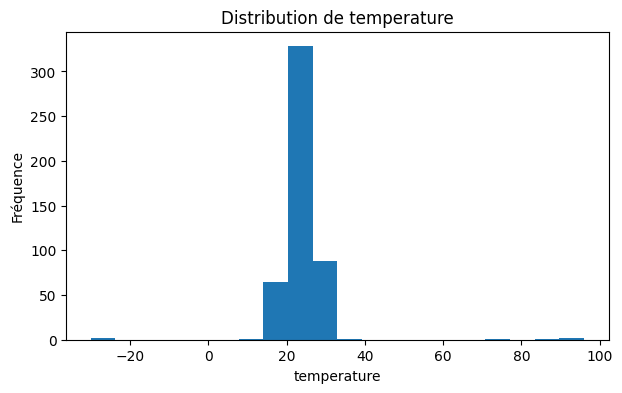

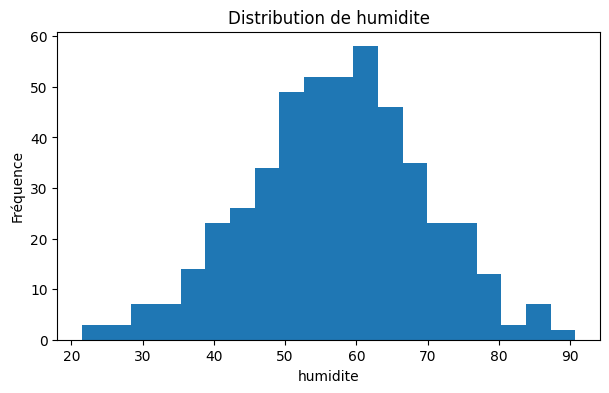

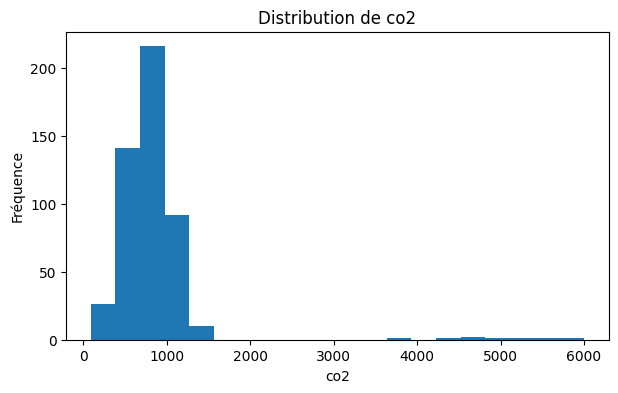

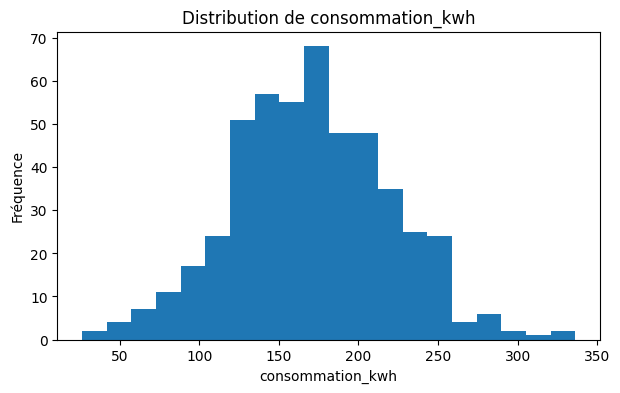

In [ ]:
import matplotlib.pyplot as plt

variables = ["temperature", "humidite", "co2", "consommation_kwh"]

for colonne in variables:
    plt.figure(figsize=(7, 4))
    plt.hist(df[colonne].dropna(), bins=20)
    plt.title("Distribution de " + colonne)
    plt.xlabel(colonne)
    plt.ylabel("Fréquence")
    plt.show()

Température : distribution non symétrique, très concentrée autour de 20–30 avec quelques valeurs très éloignées.
Humidité : distribution globalement symétrique, centrée autour de 55–65.
CO₂ : distribution non symétrique, avec une asymétrie à droite.
Consommation : distribution légèrement non symétrique, avec une asymétrie à droite.

b) La dispersion

Température : faible dispersion pour la majorité des valeurs, mais l’étendue totale est importante à cause des valeurs éloignées.
Humidité : dispersion modérée.
CO₂ : forte dispersion, avec des valeurs très éloignées de la majorité.
Consommation : dispersion assez importante.

c) Les valeurs extrêmes

Température : environ -25 et jusqu’à 95.
Humidité : environ 25 à 90.
CO₂ : environ 300 à 6 000.
Consommation : environ 40 à 340.